# Richardson-Lucy Deconvolution Tutorial

This notebook demonstrates the usage of the Richardson-Lucy deconvolution algorithms implemented in the `stemdiff.Deconv_class` module.

## What is Deconvolution?

Deconvolution is the process of reversing the effects of convolution on recorded data. In image processing, it's used to restore images that have been degraded by blurring and noise. The Richardson-Lucy algorithm is an iterative procedure for recovering an underlying image that has been blurred by a known Point Spread Function (PSF).

## Available Methods

1. **deconvRL**: Basic Richardson-Lucy algorithm
2. **deconvRLTM**: Richardson-Lucy with Tikhonov-Miller regularization
3. **deconvRLTV**: Richardson-Lucy with Total Variation regularization

Regularization helps reduce noise and artifacts in the deconvolved image.

## Setup and Imports

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import cv2

from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from Deconv_class import *
from Img_blur import *

# Set up matplotlib for better figures
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Define ImageBlurring Class and Load Image

First, let's define the ImageBlurring class and load an image from your file system.

In [9]:
# Define the ImageBlurring class
class ImageBlurring:
    def __init__(self, display=True):
        self.display = display

    def load_image(self, image_path: str):
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float64)
        print(f'Image shape is', image.shape)
        image = (image - image.min()) / (image.max() - image.min())
        print(f'Image max value after normalization is', image.max())
        return image

    def gaussian_blur(self, image, kernel_size: (int, int), sigma_x: int, save_blurred: bool = False, 
                     save_kernel: bool = False, output_image_path: str = 'blurred_image.jpg'):
        self.image = image
        kernel = cv2.getGaussianKernel(kernel_size[0], sigma_x)
        kernel = np.outer(kernel, kernel.transpose())
        blurred = cv2.filter2D(self.image, -1, kernel)
        blurred = self.add_gaussian_noise(blurred)

        if save_blurred:
            cv2.imwrite(output_image_path, blurred)
            print(f"The file is saved at {output_image_path}")

        if save_kernel:
            np.savetxt('gaussian_kernel.txt', kernel, fmt='%f')
            print("The kernel is saved at gaussian_kernel.txt")
        if self.display == 1:
            plt.imshow(blurred, cmap='gray')
            plt.title('Blurred')
            plt.xticks([]), plt.yticks([])
            plt.show()

        return blurred, kernel

    def motion_blur(self, image, size, angle):
        # size of the kernel should be an odd number
        size = size if size % 2 == 1 else size + 1
        kernel_motion_blur = np.zeros((size, size))
        kernel_motion_blur[int((size - 1) / 2), :] = np.ones(size)
        kernel_motion_blur = kernel_motion_blur / size
        # create a rotation matrix
        M = cv2.getRotationMatrix2D((size / 2 - 1, size / 2 - 1), angle, 1)
        # warp the blur kernel using the rotation matrix
        kernel_motion_blur = cv2.warpAffine(kernel_motion_blur, M, (size, size))
        output = cv2.filter2D(image, -1, kernel_motion_blur)

        if self.display == 1:
            plt.imshow(output, cmap='gray')
            plt.title('Motion Blurred')
            plt.xticks([]), plt.yticks([])
            plt.show()

        return output, kernel_motion_blur

    def add_gaussian_noise(self, image, mean=0, var=0.0005):
        row, col = image.shape
        sigma = var**0.5
        gauss = np.random.normal(mean, sigma, (row, col))
        gauss = gauss.reshape(row, col)
        noisy = image + gauss
        return noisy

Image shape is (512, 513)
Image max value after normalization is 1.0
Image dtype: float64
Image range: [0.000, 1.000]


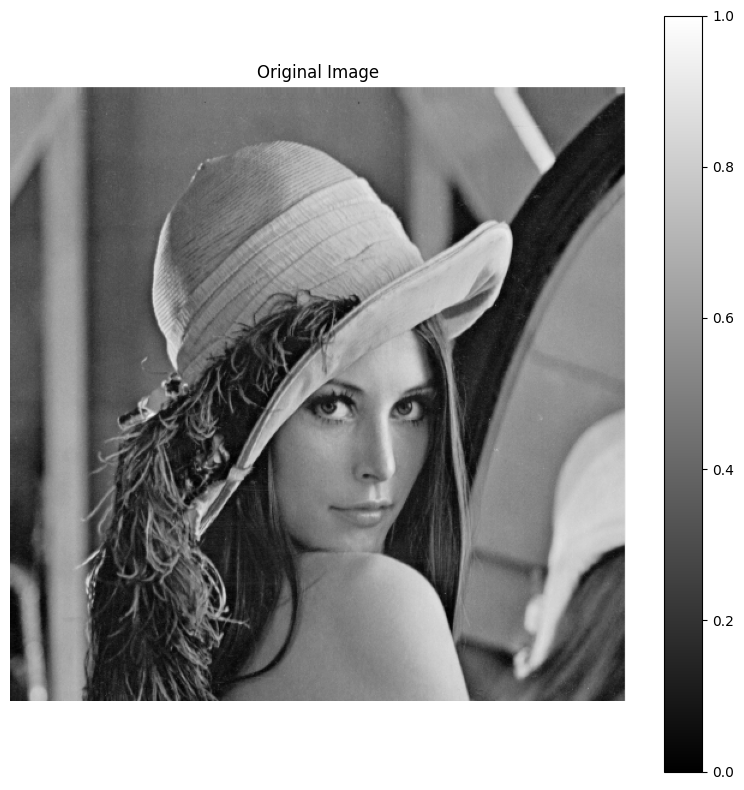

In [10]:
# Initialize ImageBlurring class
blur_processor = ImageBlurring(display=False)

# Load your image - REPLACE THIS PATH WITH YOUR IMAGE
IMAGE_PATH = r"C:\Users\drend\OneDrive\Plocha\VU\Lena.png" # ← Change this to your image path

# Load the image
image = blur_processor.load_image(IMAGE_PATH)

print(f"Image dtype: {image.dtype}")
print(f"Image range: [{image.min():.3f}, {image.max():.3f}]")

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.colorbar()
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Blur the Image Using ImageBlurring Class

We'll use the ImageBlurring class to create both Gaussian and motion blur. The class automatically adds noise to the blurred images.

### 2.1 Gaussian Blur

PSF shape: (15, 15)
PSF sum (should be ~1): 1.000000


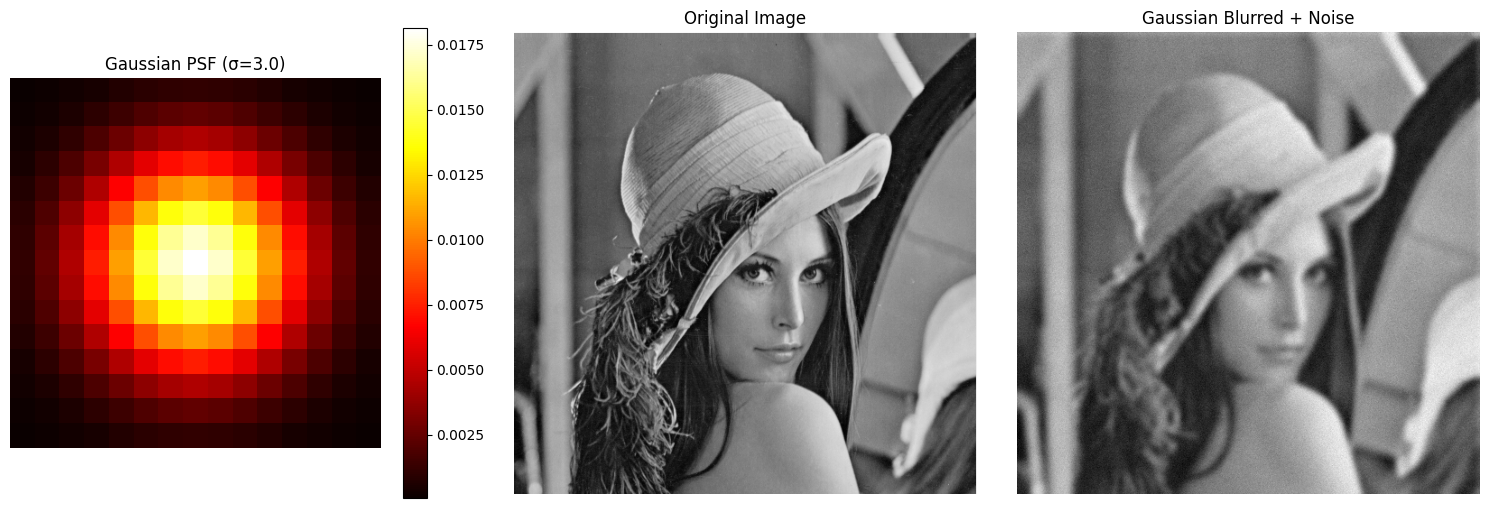


PSNR (blurred vs original): 23.72 dB


In [11]:
# Create Gaussian blur
kernel_size = (15, 15)  # Must be odd numbers
sigma_x = 3.0

# Apply Gaussian blur (includes noise)
blurred_gaussian, psf_gaussian = blur_processor.gaussian_blur(
    image, 
    kernel_size=kernel_size, 
    sigma_x=sigma_x,
    save_blurred=False,
    save_kernel=False
)

print(f"PSF shape: {psf_gaussian.shape}")
print(f"PSF sum (should be ~1): {psf_gaussian.sum():.6f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(psf_gaussian, cmap='hot')
axes[0].set_title(f'Gaussian PSF (σ={sigma_x})')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

axes[1].imshow(image, cmap='gray')
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(blurred_gaussian, cmap='gray')
axes[2].set_title('Gaussian Blurred + Noise')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nPSNR (blurred vs original): {psnr(image, blurred_gaussian):.2f} dB")

### 2.2 Motion Blur (Optional Alternative)

PSF shape: (15, 15)
PSF sum (should be ~1): 0.967904


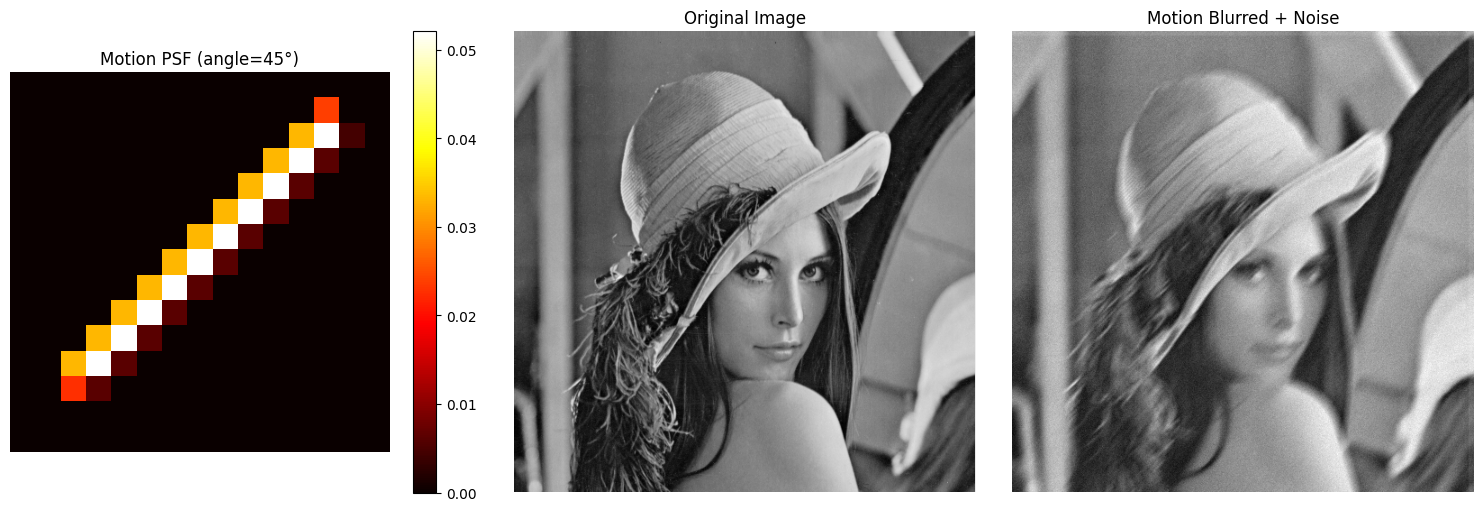


PSNR (blurred vs original): 23.23 dB


In [12]:
# Create Motion blur (alternative to Gaussian blur)
motion_size = 15  # Will be made odd automatically
motion_angle = 45  # degrees

# Apply motion blur
blurred_motion, psf_motion = blur_processor.motion_blur(
    image,
    size=motion_size,
    angle=motion_angle
)

# Add noise separately for motion blur
blurred_motion = blur_processor.add_gaussian_noise(blurred_motion, mean=0, var=0.0005)

print(f"PSF shape: {psf_motion.shape}")
print(f"PSF sum (should be ~1): {psf_motion.sum():.6f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(psf_motion, cmap='hot')
axes[0].set_title(f'Motion PSF (angle={motion_angle}°)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

axes[1].imshow(image, cmap='gray')
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(blurred_motion, cmap='gray')
axes[2].set_title('Motion Blurred + Noise')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nPSNR (blurred vs original): {psnr(image, blurred_motion):.2f} dB")

In [13]:
# Choose which blur type to use for the rest of the tutorial
# Option 1: Gaussian blur (default)
blurred_noisy = blurred_gaussian
psf = psf_gaussian

# Option 2: Motion blur (uncomment to use instead)
# blurred_noisy = blurred_motion
# psf = psf_motion

print(f"Using PSF shape: {psf.shape}")
print(f"Blurred image range: [{blurred_noisy.min():.3f}, {blurred_noisy.max():.3f}]")

Using PSF shape: (15, 15)
Blurred image range: [-0.014, 0.919]


## 3. Basic Richardson-Lucy Deconvolution

First, let's try the basic Richardson-Lucy algorithm without regularization.

100%|██████████| 29/29 [00:02<00:00, 12.80it/s]


Deconvolution took 2.2678914070129395 seconds for 30 iterations.


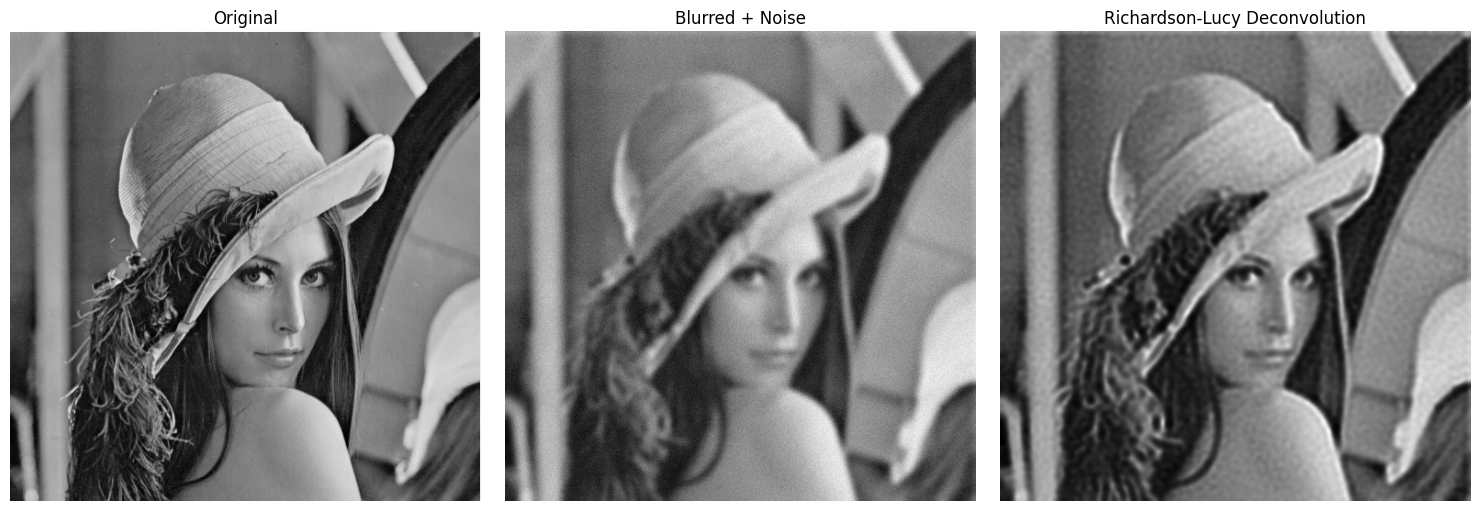


PSNR (deconvolved vs original): 25.75 dB


ValueError: Since image dtype is floating point, you must specify the data_range parameter. Please read the documentation carefully (including the note). It is recommended that you always specify the data_range anyway.

In [14]:
# Initialize the deconvolution class
# Using CPU for compatibility (set cuda=True if you have GPU support)
rl_basic = RichardsonLucy(
    iterations=30,
    cuda=False,  # Set to True if you have CUDA support
    display=False,
    timer=True,
    turn_off_progress_bar=False
)

# Perform deconvolution
deconv_basic = rl_basic.deconvRL(blurred_noisy, psf)

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(blurred_noisy, cmap='gray')
axes[1].set_title('Blurred + Noise')
axes[1].axis('off')

axes[2].imshow(deconv_basic, cmap='gray')
axes[2].set_title('Richardson-Lucy Deconvolution')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nPSNR (deconvolved vs original): {psnr(image, deconv_basic):.2f} dB")
print(f"SSIM (deconvolved vs original): {ssim(image, deconv_basic):.4f}")

## 4. Effect of Iteration Count

Let's explore how the number of iterations affects the result.

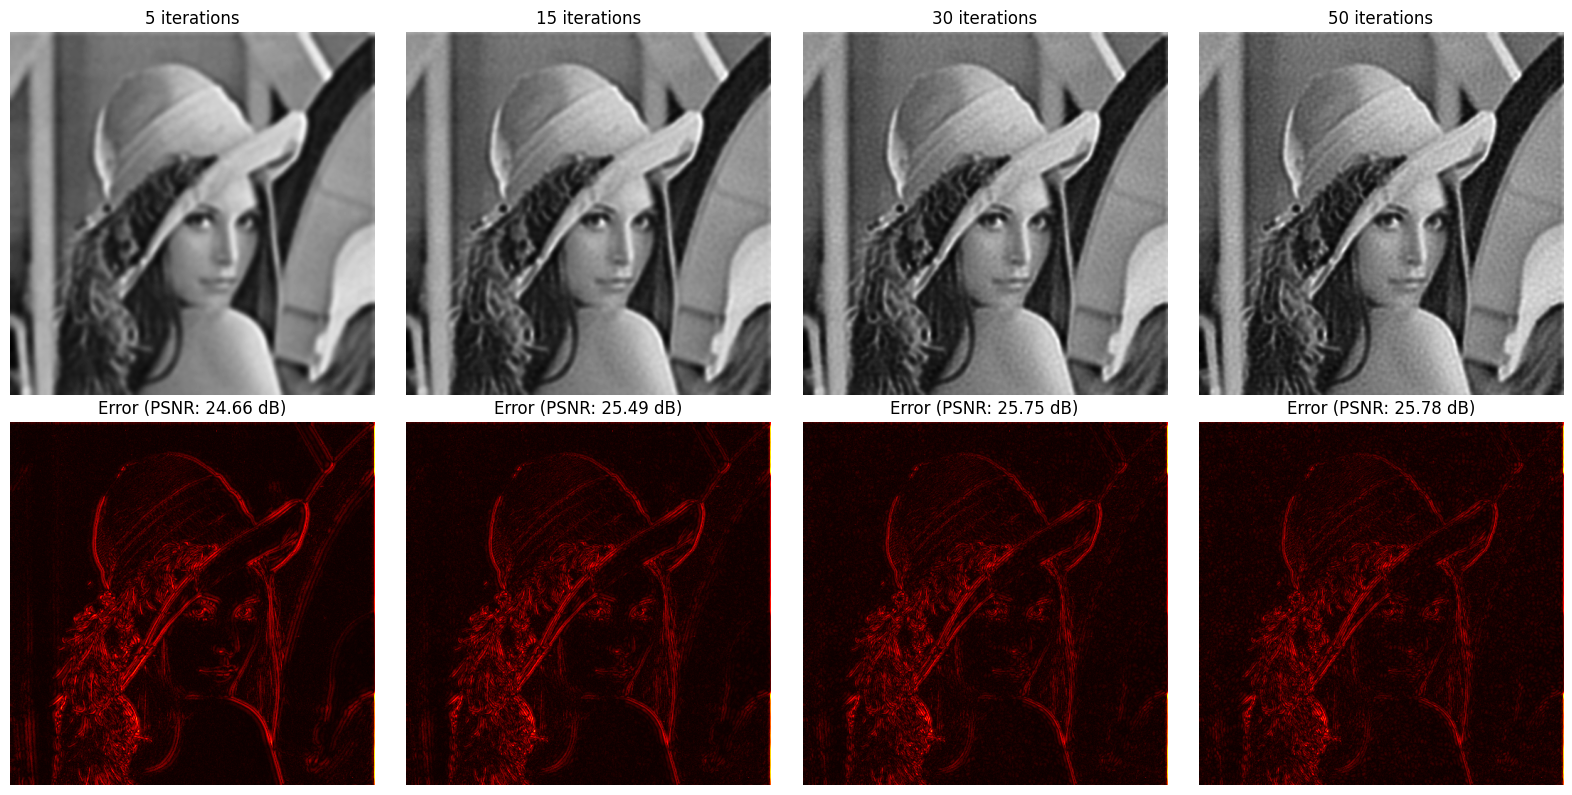

In [15]:
iteration_counts = [5, 15, 30, 50]
results = []

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, n_iter in enumerate(iteration_counts):
    rl = RichardsonLucy(
        iterations=n_iter,
        cuda=False,
        display=False,
        timer=False,
        turn_off_progress_bar=True
    )
    deconv = rl.deconvRL(blurred_noisy, psf)
    results.append(deconv)
    
    # Show result
    axes[0, idx].imshow(deconv, cmap='gray')
    axes[0, idx].set_title(f'{n_iter} iterations')
    axes[0, idx].axis('off')
    
    # Show difference from original
    diff = np.abs(image - deconv)
    axes[1, idx].imshow(diff, cmap='hot')
    axes[1, idx].set_title(f'Error (PSNR: {psnr(image, deconv):.2f} dB)')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

## 5. Richardson-Lucy with Tikhonov-Miller Regularization (RLTM)

Tikhonov regularization helps reduce noise amplification by penalizing high-frequency components.

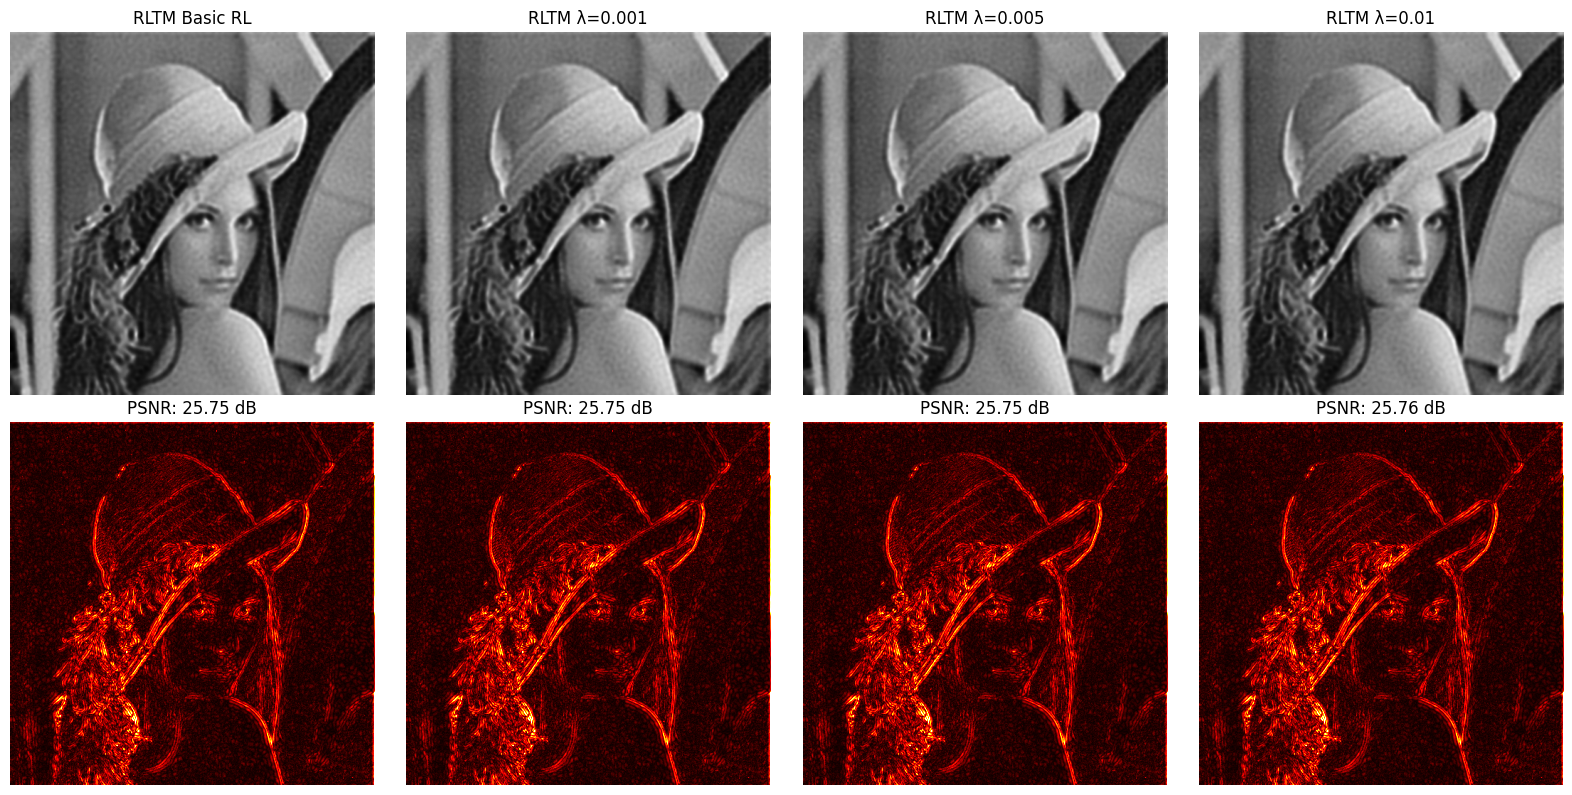

In [16]:
# Test different regularization parameters
lambda_values = [0.0, 0.001, 0.005, 0.01]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, lambda_reg in enumerate(lambda_values):
    rl_tm = RichardsonLucy(
        iterations=30,
        cuda=False,
        display=False,
        timer=False,
        turn_off_progress_bar=True
    )
    
    if lambda_reg == 0.0:
        # Use basic RL for comparison
        deconv = rl_tm.deconvRL(blurred_noisy, psf)
        title_suffix = 'Basic RL'
    else:
        deconv = rl_tm.deconvRLTM(blurred_noisy, psf, lambda_reg)
        title_suffix = f'λ={lambda_reg}'
    
    # Show result
    axes[0, idx].imshow(deconv, cmap='gray')
    axes[0, idx].set_title(f'RLTM {title_suffix}')
    axes[0, idx].axis('off')
    
    # Show difference
    diff = np.abs(image - deconv)
    axes[1, idx].imshow(diff, cmap='hot', vmin=0, vmax=0.3)
    axes[1, idx].set_title(f'PSNR: {psnr(image, deconv):.2f} dB')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

## 6. Richardson-Lucy with Total Variation Regularization (RLTV)

Total Variation regularization is edge-preserving and often produces sharper results than Tikhonov regularization.

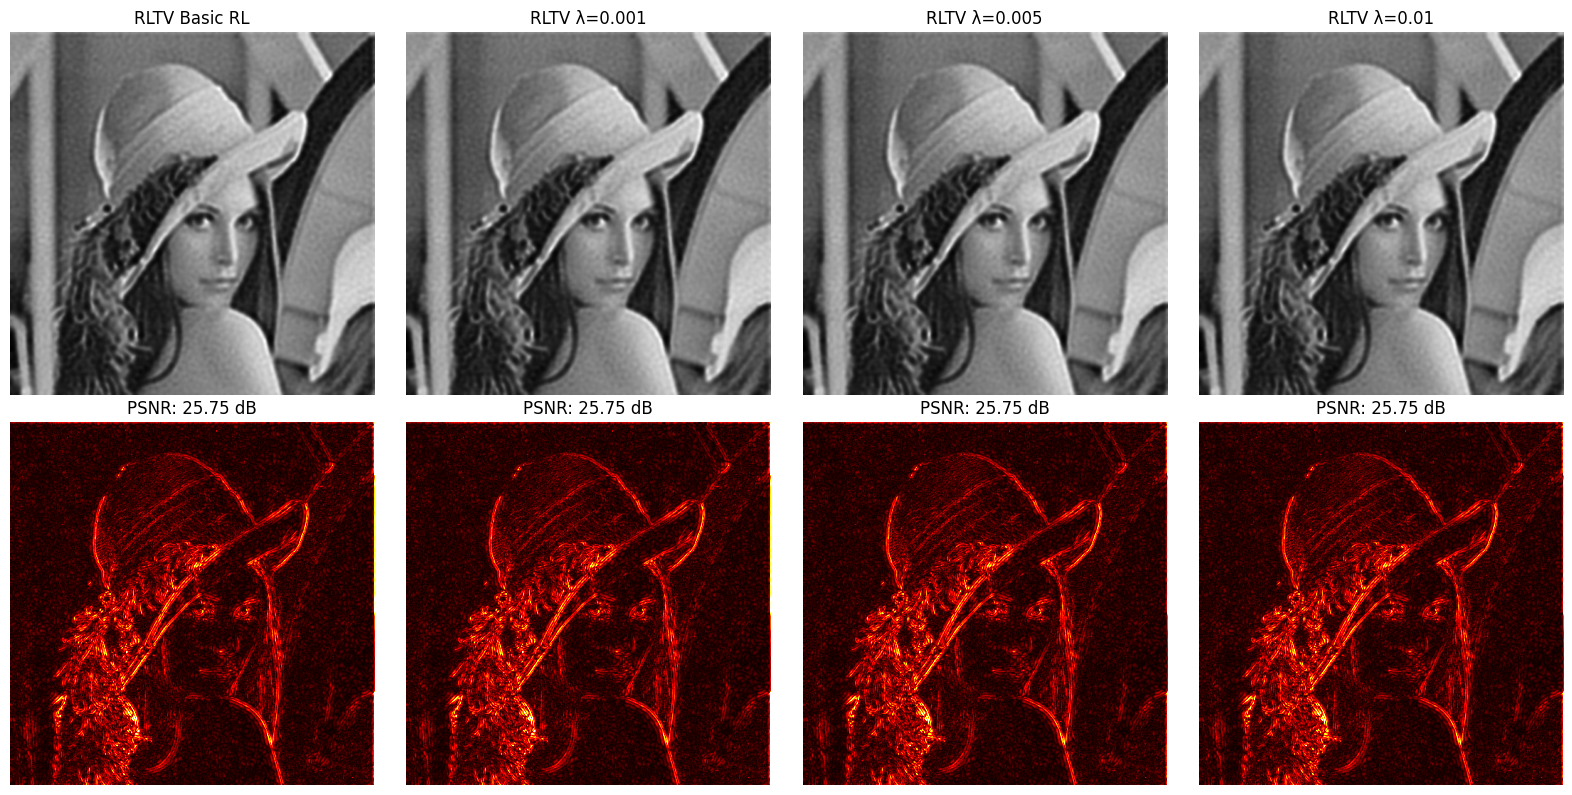

In [17]:
# Test different regularization parameters
lambda_values_tv = [0.0, 0.001, 0.005, 0.01]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, lambda_reg in enumerate(lambda_values_tv):
    rl_tv = RichardsonLucy(
        iterations=30,
        cuda=False,
        display=False,
        timer=False,
        turn_off_progress_bar=True
    )
    
    if lambda_reg == 0.0:
        # Use basic RL for comparison
        deconv = rl_tv.deconvRL(blurred_noisy, psf)
        title_suffix = 'Basic RL'
    else:
        deconv = rl_tv.deconvRLTV(blurred_noisy, psf, lambda_reg)
        title_suffix = f'λ={lambda_reg}'
    
    # Show result
    axes[0, idx].imshow(deconv, cmap='gray')
    axes[0, idx].set_title(f'RLTV {title_suffix}')
    axes[0, idx].axis('off')
    
    # Show difference
    diff = np.abs(image - deconv)
    axes[1, idx].imshow(diff, cmap='hot', vmin=0, vmax=0.3)
    axes[1, idx].set_title(f'PSNR: {psnr(image, deconv):.2f} dB')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

## 7. Direct Comparison of All Three Methods

Let's compare the three methods side-by-side with optimal parameters.

Deconvolution took 2.2618155479431152 seconds for 30 iterations.
Deconvolution took 2.3649818897247314 seconds for 30 iterations.
Deconvolution took 2.998169183731079 seconds for 30 iterations.


C:\Users\drend\AppData\Local\Temp\ipykernel_28868\2058162750.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


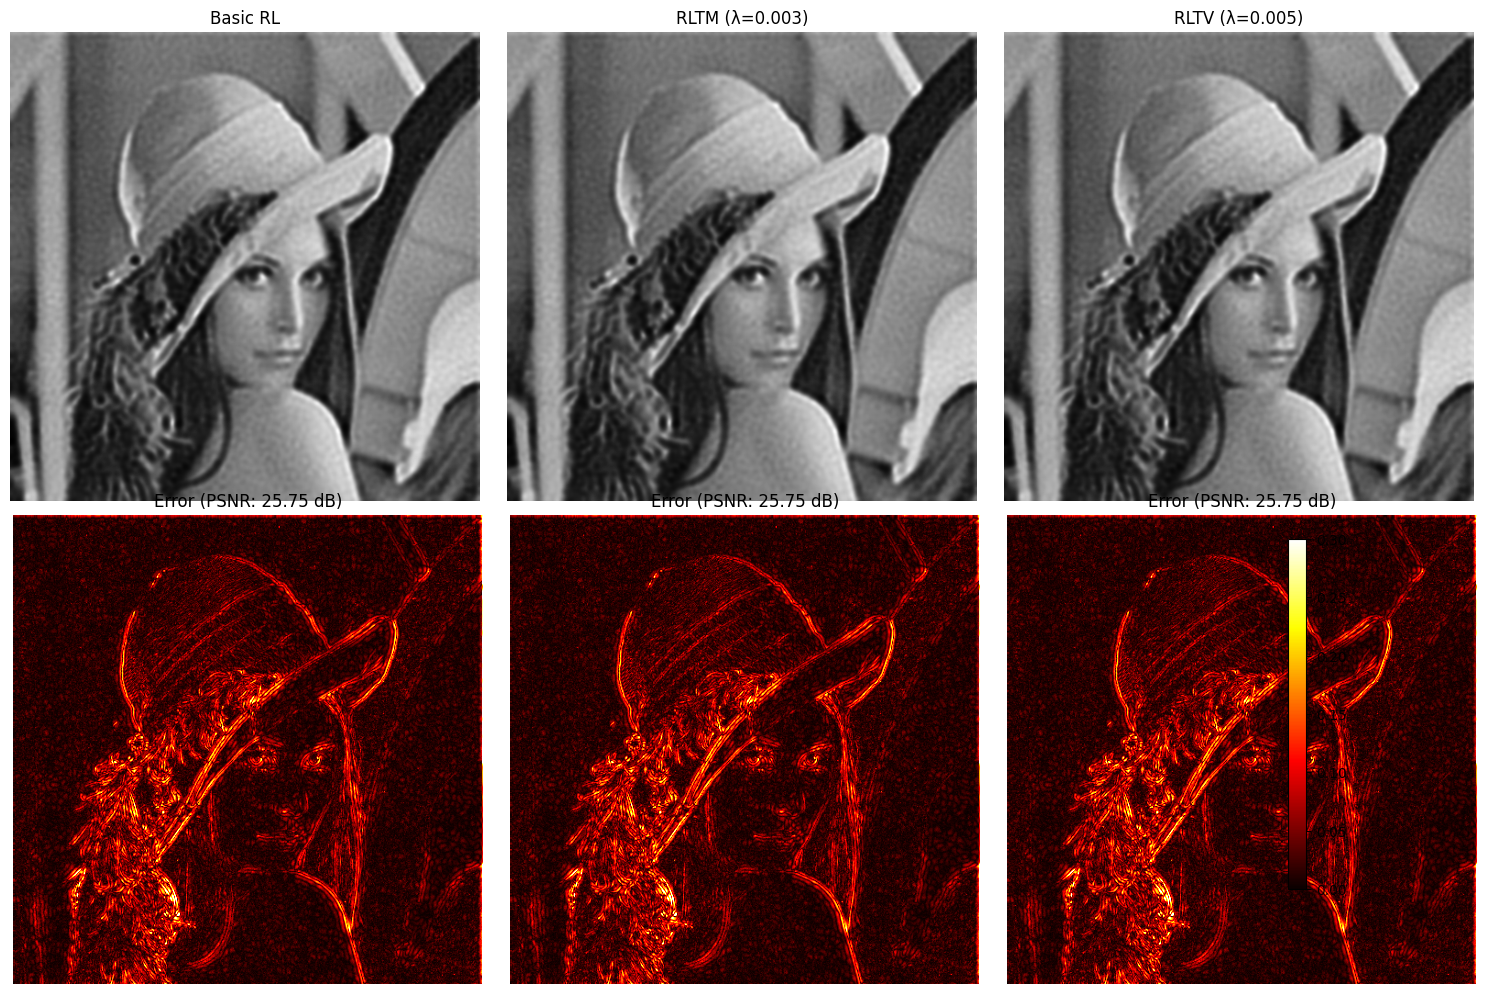


COMPARISON METRICS
Method               PSNR (dB)       SSIM
------------------------------------------------------------


ValueError: Since image dtype is floating point, you must specify the data_range parameter. Please read the documentation carefully (including the note). It is recommended that you always specify the data_range anyway.

In [18]:
# Set parameters
n_iterations = 30
lambda_tm = 0.003  # Optimal for Tikhonov-Miller
lambda_tv = 0.005  # Optimal for Total Variation

# Basic RL
rl1 = RichardsonLucy(iterations=n_iterations, cuda=False, display=False, 
                     timer=True, turn_off_progress_bar=True)
deconv_rl = rl1.deconvRL(blurred_noisy, psf)

# RLTM
rl2 = RichardsonLucy(iterations=n_iterations, cuda=False, display=False, 
                     timer=True, turn_off_progress_bar=True)
deconv_tm = rl2.deconvRLTM(blurred_noisy, psf, lambda_tm)

# RLTV
rl3 = RichardsonLucy(iterations=n_iterations, cuda=False, display=False, 
                     timer=True, turn_off_progress_bar=True)
deconv_tv = rl3.deconvRLTV(blurred_noisy, psf, lambda_tv)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: deconvolved images
axes[0, 0].imshow(deconv_rl, cmap='gray')
axes[0, 0].set_title('Basic RL')
axes[0, 0].axis('off')

axes[0, 1].imshow(deconv_tm, cmap='gray')
axes[0, 1].set_title(f'RLTM (λ={lambda_tm})')
axes[0, 1].axis('off')

axes[0, 2].imshow(deconv_tv, cmap='gray')
axes[0, 2].set_title(f'RLTV (λ={lambda_tv})')
axes[0, 2].axis('off')

# Bottom row: error maps
diff_rl = np.abs(image - deconv_rl)
diff_tm = np.abs(image - deconv_tm)
diff_tv = np.abs(image - deconv_tv)

im1 = axes[1, 0].imshow(diff_rl, cmap='hot', vmin=0, vmax=0.3)
axes[1, 0].set_title(f'Error (PSNR: {psnr(image, deconv_rl):.2f} dB)')
axes[1, 0].axis('off')

im2 = axes[1, 1].imshow(diff_tm, cmap='hot', vmin=0, vmax=0.3)
axes[1, 1].set_title(f'Error (PSNR: {psnr(image, deconv_tm):.2f} dB)')
axes[1, 1].axis('off')

im3 = axes[1, 2].imshow(diff_tv, cmap='hot', vmin=0, vmax=0.3)
axes[1, 2].set_title(f'Error (PSNR: {psnr(image, deconv_tv):.2f} dB)')
axes[1, 2].axis('off')

plt.colorbar(im3, ax=axes[1, :], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Print metrics
print("\n" + "="*60)
print("COMPARISON METRICS")
print("="*60)
print(f"{'Method':<20} {'PSNR (dB)':<15} {'SSIM'}")
print("-"*60)
print(f"{'Blurred+Noise':<20} {psnr(image, blurred_noisy):<15.2f} {ssim(image, blurred_noisy):.4f}")
print(f"{'Basic RL':<20} {psnr(image, deconv_rl):<15.2f} {ssim(image, deconv_rl):.4f}")
print(f"{'RLTM':<20} {psnr(image, deconv_tm):<15.2f} {ssim(image, deconv_tm):.4f}")
print(f"{'RLTV':<20} {psnr(image, deconv_tv):<15.2f} {ssim(image, deconv_tv):.4f}")
print("="*60)

## 8. Zoomed Comparison for Detail Analysis

Let's zoom into a specific region to see the differences more clearly.

In [ ]:
# Select a region of interest (adjust coordinates as needed)
y_start, y_end = 100, 200
x_start, x_end = 150, 250

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original and blurred
axes[0, 0].imshow(image[y_start:y_end, x_start:x_end], cmap='gray')
axes[0, 0].set_title('Original (Zoomed)')
axes[0, 0].axis('off')

axes[0, 1].imshow(blurred_noisy[y_start:y_end, x_start:x_end], cmap='gray')
axes[0, 1].set_title('Blurred + Noise (Zoomed)')
axes[0, 1].axis('off')

# Deconvolved results
axes[0, 2].imshow(deconv_rl[y_start:y_end, x_start:x_end], cmap='gray')
axes[0, 2].set_title('Basic RL (Zoomed)')
axes[0, 2].axis('off')

axes[1, 0].imshow(deconv_tm[y_start:y_end, x_start:x_end], cmap='gray')
axes[1, 0].set_title('RLTM (Zoomed)')
axes[1, 0].axis('off')

axes[1, 1].imshow(deconv_tv[y_start:y_end, x_start:x_end], cmap='gray')
axes[1, 1].set_title('RLTV (Zoomed)')
axes[1, 1].axis('off')

# Full image with ROI marked
axes[1, 2].imshow(image, cmap='gray')
from matplotlib.patches import Rectangle
rect = Rectangle((x_start, y_start), x_end-x_start, y_end-y_start, 
                 linewidth=2, edgecolor='r', facecolor='none')
axes[1, 2].add_patch(rect)
axes[1, 2].set_title('ROI Location')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 9. Complete Workflow Template

Here's a complete template for processing your own images from start to finish.

In [ ]:
def complete_deconvolution_workflow(image_path, blur_type='gaussian', method='RLTV', 
                                   iterations=30, lambda_reg=0.005, use_cuda=False,
                                   kernel_size=(15, 15), sigma_x=3.0,
                                   motion_size=15, motion_angle=45):
    """
    Complete workflow: Load image -> Blur -> Deconvolve.
    
    Parameters:
    -----------
    image_path : str
        Path to the image file
    blur_type : str
        'gaussian' or 'motion'
    method : str
        'RL', 'RLTM', or 'RLTV'
    iterations : int
        Number of iterations
    lambda_reg : float
        Regularization parameter (for RLTM and RLTV)
    use_cuda : bool
        Use GPU acceleration if available
    kernel_size : tuple
        Gaussian kernel size (must be odd)
    sigma_x : float
        Gaussian sigma
    motion_size : int
        Motion blur kernel size
    motion_angle : float
        Motion blur angle in degrees
    
    Returns:
    --------
    dict with 'original', 'blurred', 'deconvolved', 'psf'
    """
    # Initialize processors
    blur_proc = ImageBlurring(display=False)
    
    # Load image
    print("Loading image...")
    original = blur_proc.load_image(image_path)
    
    # Apply blur
    print(f"Applying {blur_type} blur...")
    if blur_type == 'gaussian':
        blurred, psf = blur_proc.gaussian_blur(original, kernel_size, sigma_x)
    elif blur_type == 'motion':
        blurred, psf = blur_proc.motion_blur(original, motion_size, motion_angle)
        blurred = blur_proc.add_gaussian_noise(blurred)
    else:
        raise ValueError("blur_type must be 'gaussian' or 'motion'")
    
    # Initialize deconvolution
    print(f"Applying {method} deconvolution...")
    rl = RichardsonLucy(
        iterations=iterations,
        cuda=use_cuda,
        display=False,
        timer=True,
        turn_off_progress_bar=False
    )
    
    # Apply deconvolution
    if method == 'RL':
        deconvolved = rl.deconvRL(blurred, psf)
    elif method == 'RLTM':
        deconvolved = rl.deconvRLTM(blurred, psf, lambda_reg)
    elif method == 'RLTV':
        deconvolved = rl.deconvRLTV(blurred, psf, lambda_reg)
    else:
        raise ValueError("Method must be 'RL', 'RLTM', or 'RLTV'")
    
    # Compute metrics
    psnr_blurred = psnr(original, blurred)
    psnr_deconv = psnr(original, deconvolved)
    ssim_blurred = ssim(original, blurred)
    ssim_deconv = ssim(original, deconvolved)
    
    print(f"\n{'='*60}")
    print(f"PSNR - Blurred: {psnr_blurred:.2f} dB")
    print(f"PSNR - Deconvolved: {psnr_deconv:.2f} dB (Δ: {psnr_deconv-psnr_blurred:+.2f} dB)")
    print(f"SSIM - Blurred: {ssim_blurred:.4f}")
    print(f"SSIM - Deconvolved: {ssim_deconv:.4f} (Δ: {ssim_deconv-ssim_blurred:+.4f})")
    print(f"{'='*60}")
    
    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(original, cmap='gray')
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(blurred, cmap='gray')
    axes[0, 1].set_title(f'{blur_type.capitalize()} Blurred')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(deconvolved, cmap='gray')
    axes[0, 2].set_title(f'{method} Deconvolved')
    axes[0, 2].axis('off')
    
    im0 = axes[1, 0].imshow(psf, cmap='hot')
    axes[1, 0].set_title('PSF')
    axes[1, 0].axis('off')
    plt.colorbar(im0, ax=axes[1, 0])
    
    diff_blurred = np.abs(original - blurred)
    im1 = axes[1, 1].imshow(diff_blurred, cmap='hot')
    axes[1, 1].set_title(f'Error: Blurred (PSNR: {psnr_blurred:.2f})')
    axes[1, 1].axis('off')
    plt.colorbar(im1, ax=axes[1, 1])
    
    diff_deconv = np.abs(original - deconvolved)
    im2 = axes[1, 2].imshow(diff_deconv, cmap='hot')
    axes[1, 2].set_title(f'Error: Deconvolved (PSNR: {psnr_deconv:.2f})')
    axes[1, 2].axis('off')
    plt.colorbar(im2, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.show()
    
    return {
        'original': original,
        'blurred': blurred,
        'deconvolved': deconvolved,
        'psf': psf,
        'metrics': {
            'psnr_blurred': psnr_blurred,
            'psnr_deconvolved': psnr_deconv,
            'ssim_blurred': ssim_blurred,
            'ssim_deconvolved': ssim_deconv
        }
    }

# Example usage:
# result = complete_deconvolution_workflow(
#     image_path='path/to/your/image.png',
#     blur_type='gaussian',
#     method='RLTV',
#     iterations=30,
#     lambda_reg=0.005,
#     use_cuda=False
# )

### Save Deconvolved Images

In [ ]:
# Save deconvolution results
def save_results(deconvolved_image, output_path='deconvolved_result.png'):
    """
    Save deconvolved image to file.
    
    Parameters:
    -----------
    deconvolved_image : np.ndarray
        Deconvolved image (float, 0-1 range)
    output_path : str
        Path to save the image
    """
    # Convert to 8-bit for saving
    image_8bit = (np.clip(deconvolved_image, 0, 1) * 255).astype(np.uint8)
    cv2.imwrite(output_path, image_8bit)
    print(f"Image saved to: {output_path}")

# Example:
# save_results(deconv_tv, 'my_deconvolved_image.png')

## 10. Working with Real Blurred Images

If you already have a blurred image and know (or can estimate) the PSF, you can deconvolve directly without artificial blurring.

In [ ]:
def deconvolve_real_image(blurred_image_path, psf, method='RLTV', 
                          iterations=30, lambda_reg=0.005, use_cuda=False,
                          output_path='deconvolved.png'):
    """
    Deconvolve an already-blurred image.
    
    Parameters:
    -----------
    blurred_image_path : str
        Path to the blurred image
    psf : np.ndarray
        Known or estimated PSF
    method : str
        'RL', 'RLTM', or 'RLTV'
    iterations : int
        Number of iterations
    lambda_reg : float
        Regularization parameter
    use_cuda : bool
        Use GPU if available
    output_path : str
        Path to save result
    
    Returns:
    --------
    deconvolved : np.ndarray
        Deconvolved image
    """
    # Load blurred image
    blur_proc = ImageBlurring(display=False)
    blurred = blur_proc.load_image(blurred_image_path)
    
    # Initialize deconvolution
    rl = RichardsonLucy(
        iterations=iterations,
        cuda=use_cuda,
        display=False,
        timer=True,
        turn_off_progress_bar=False
    )
    
    # Deconvolve
    print(f"Deconvolving with {method}...")
    if method == 'RL':
        result = rl.deconvRL(blurred, psf)
    elif method == 'RLTM':
        result = rl.deconvRLTM(blurred, psf, lambda_reg)
    elif method == 'RLTV':
        result = rl.deconvRLTV(blurred, psf, lambda_reg)
    else:
        raise ValueError("Method must be 'RL', 'RLTM', or 'RLTV'")
    
    # Save result
    result_8bit = (np.clip(result, 0, 1) * 255).astype(np.uint8)
    cv2.imwrite(output_path, result_8bit)
    print(f"Deconvolved image saved to: {output_path}")
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    im0 = axes[0].imshow(psf, cmap='hot')
    axes[0].set_title('PSF Used')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0])
    
    axes[1].imshow(blurred, cmap='gray')
    axes[1].set_title('Blurred Input')
    axes[1].axis('off')
    
    axes[2].imshow(result, cmap='gray')
    axes[2].set_title(f'{method} Deconvolved')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return result

# Example usage:
# # If you have a blurred image and know the PSF
# known_psf = cv2.getGaussianKernel(15, 3.0)
# known_psf = np.outer(known_psf, known_psf.transpose())
# 
# result = deconvolve_real_image(
#     blurred_image_path='my_blurred_photo.jpg',
#     psf=known_psf,
#     method='RLTV',
#     iterations=30,
#     lambda_reg=0.005,
#     output_path='restored_photo.png'
# )

## 11. Tips and Best Practices

### Choosing the Right Method:

1. **Basic RL (`deconvRL`)**:
   - Fast and simple
   - Good for low-noise images
   - Can amplify noise with too many iterations

2. **RLTM (`deconvRLTM`)**:
   - Good noise suppression
   - Smooths the image slightly
   - Use λ ≈ 0.001-0.01

3. **RLTV (`deconvRLTV`)**:
   - Edge-preserving
   - Best for images with sharp features
   - Can be slower than RLTM
   - Use λ ≈ 0.001-0.01

### Parameter Selection:

- **Iterations**: Start with 20-30. Too many can amplify noise.
- **Lambda (regularization)**: Start small (0.001) and increase if needed.
- **CUDA**: Enable if you have GPU support for 5-10x speedup.

### Common Issues:

- **Over-sharpening**: Reduce iterations or increase lambda
- **Noise amplification**: Use RLTM or RLTV instead of basic RL
- **Ringing artifacts**: Increase regularization parameter
- **Blurry result**: Increase iterations or decrease lambda

## Summary

This tutorial demonstrated:
1. Basic image loading and PSF creation
2. Artificial blurring for testing
3. Three Richardson-Lucy variants (RL, RLTM, RLTV)
4. Parameter optimization
5. Visual and quantitative comparison

The Richardson-Lucy algorithm is powerful for restoring blurred images, and the regularized variants help manage noise while preserving important image features.